In [2]:
# Day 1

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Load both datasets
print("Loading data...")
train_transaction = pd.read_csv('train_transaction.csv')
train_identity = pd.read_csv('train_identity.csv')

print("Transaction shape:", train_transaction.shape)
print("Identity shape:", train_identity.shape)

Loading data...
Transaction shape: (590540, 394)
Identity shape: (144233, 41)


In [4]:
# Merge both datasets
df = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')

print("Merged dataset shape:", df.shape)
print("\nFraud Distribution:")
print(df['isFraud'].value_counts())
print("\nFraud Percentage:")
print(df['isFraud'].value_counts(normalize=True) * 100)

Merged dataset shape: (590540, 434)

Fraud Distribution:
isFraud
0    569877
1     20663
Name: count, dtype: int64

Fraud Percentage:
isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64


In [5]:
# Check important columns
print("Key columns in dataset:")
print("\nTransaction columns sample:")
print(train_transaction.columns[:20].tolist())

print("\nIdentity columns sample:")
print(train_identity.columns[:10].tolist())

print("\nBasic statistics:")
print(df[['TransactionAmt', 'isFraud']].describe())

Key columns in dataset:

Transaction columns sample:
['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3']

Identity columns sample:
['TransactionID', 'id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06', 'id_07', 'id_08', 'id_09']

Basic statistics:
       TransactionAmt        isFraud
count   590540.000000  590540.000000
mean       135.027176       0.034990
std        239.162522       0.183755
min          0.251000       0.000000
25%         43.321000       0.000000
50%         68.769000       0.000000
75%        125.000000       0.000000
max      31937.391000       1.000000


In [6]:
# Check missing values
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': missing_percent
}).sort_values('Missing Percentage', ascending=False)

print("Top 20 columns with missing values:")
print(missing_df.head(20))
print(f"\nTotal columns with missing values: {(missing > 0).sum()}")

Top 20 columns with missing values:
       Missing Count  Missing Percentage
id_24         585793           99.196159
id_25         585408           99.130965
id_07         585385           99.127070
id_08         585385           99.127070
id_21         585381           99.126393
id_26         585377           99.125715
id_27         585371           99.124699
id_23         585371           99.124699
id_22         585371           99.124699
dist2         552913           93.628374
D7            551623           93.409930
id_18         545427           92.360721
D13           528588           89.509263
D14           528353           89.469469
D12           525823           89.041047
id_03         524216           88.768923
id_04         524216           88.768923
D6            517353           87.606767
id_33         517251           87.589494
id_10         515614           87.312290

Total columns with missing values: 414


In [7]:
# Drop columns with more than 50% missing values
threshold = 50
cols_to_drop = missing_df[missing_df['Missing Percentage'] > threshold].index.tolist()
print(f"Columns to drop (>50% missing): {len(cols_to_drop)}")

df_cleaned = df.drop(columns=cols_to_drop)
print(f"Shape before cleaning: {df.shape}")
print(f"Shape after cleaning: {df_cleaned.shape}")

# Check remaining missing values
remaining_missing = df_cleaned.isnull().sum().sum()
print(f"\nRemaining missing values: {remaining_missing}")

Columns to drop (>50% missing): 214
Shape before cleaning: (590540, 434)
Shape after cleaning: (590540, 220)

Remaining missing values: 14036680


In [8]:
# Fill remaining missing values
# Numerical columns - fill with median
# Categorical columns - fill with mode

numerical_cols = df_cleaned.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns

print(f"Numerical columns: {len(numerical_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

# Fill numerical with median
df_cleaned[numerical_cols] = df_cleaned[numerical_cols].fillna(df_cleaned[numerical_cols].median())

# Fill categorical with mode
for col in categorical_cols:
    df_cleaned[col].fillna(df_cleaned[col].mode()[0], inplace=True)

# Verify
print(f"\nMissing values after filling: {df_cleaned.isnull().sum().sum()}")
print("Data cleaning complete!")

Numerical columns: 211
Categorical columns: 9

Missing values after filling: 1361708
Data cleaning complete!


In [9]:
# Fill remaining missing values with 0
df_cleaned = df_cleaned.fillna(0)

# Verify
print(f"Missing values after final fill: {df_cleaned.isnull().sum().sum()}")
print(f"Final dataset shape: {df_cleaned.shape}")
print("All missing values handled!")

Missing values after final fill: 0
Final dataset shape: (590540, 220)
All missing values handled!


In [10]:
# Save cleaned data checkpoint
print("Dataset Overview:")
print(f"Total Transactions: {len(df_cleaned):,}")
print(f"Fraud Cases: {df_cleaned['isFraud'].sum():,}")
print(f"Normal Cases: {(df_cleaned['isFraud']==0).sum():,}")
print(f"Fraud Percentage: {df_cleaned['isFraud'].mean()*100:.2f}%")
print(f"Total Features: {df_cleaned.shape[1]-1}")
print(f"Average Transaction Amount: ${df_cleaned['TransactionAmt'].mean():.2f}")
print(f"Max Transaction Amount: ${df_cleaned['TransactionAmt'].max():.2f}")

Dataset Overview:
Total Transactions: 590,540
Fraud Cases: 20,663
Normal Cases: 569,877
Fraud Percentage: 3.50%
Total Features: 219
Average Transaction Amount: $135.03
Max Transaction Amount: $31937.39


In [11]:
# DAY 2

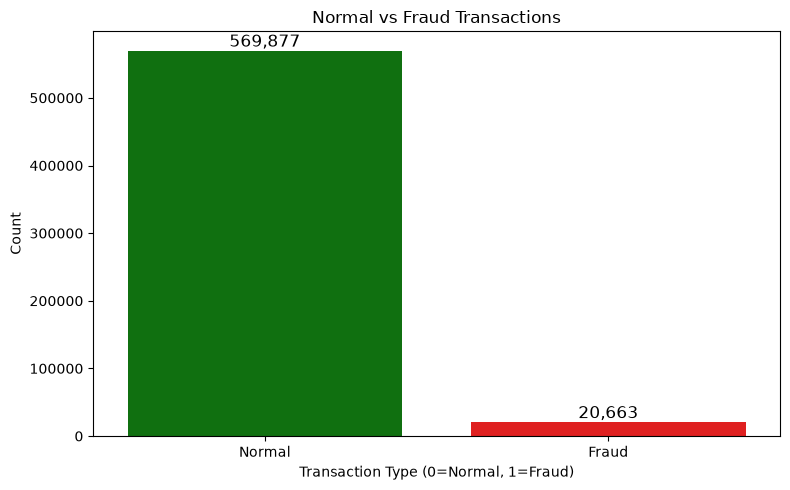

In [12]:
# Fraud vs Normal Distribution
plt.figure(figsize=(8,5))
ax = sns.countplot(data=df_cleaned, x='isFraud', palette=['green','red'])
plt.title('Normal vs Fraud Transactions')
plt.xlabel('Transaction Type (0=Normal, 1=Fraud)')
plt.ylabel('Count')
plt.xticks([0,1], ['Normal', 'Fraud'])

# Add count labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

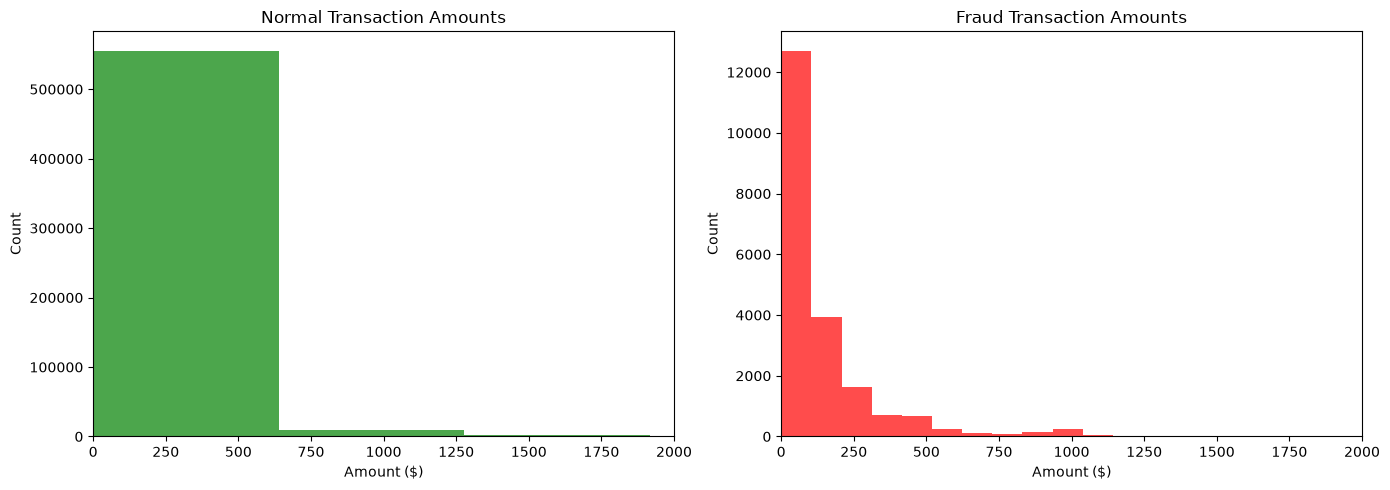

Normal - Average Amount: $ 134.51
Fraud - Average Amount: $ 149.24


In [13]:
# Transaction Amount - Fraud vs Normal
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].hist(df_cleaned[df_cleaned['isFraud']==0]['TransactionAmt'], 
             bins=50, color='green', alpha=0.7)
axes[0].set_title('Normal Transaction Amounts')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Count')
axes[0].set_xlim(0, 2000)

axes[1].hist(df_cleaned[df_cleaned['isFraud']==1]['TransactionAmt'], 
             bins=50, color='red', alpha=0.7)
axes[1].set_title('Fraud Transaction Amounts')
axes[1].set_xlabel('Amount ($)')
axes[1].set_ylabel('Count')
axes[1].set_xlim(0, 2000)

plt.tight_layout()
plt.show()

print("Normal - Average Amount: $", round(df_cleaned[df_cleaned['isFraud']==0]['TransactionAmt'].mean(), 2))
print("Fraud - Average Amount: $", round(df_cleaned[df_cleaned['isFraud']==1]['TransactionAmt'].mean(), 2))

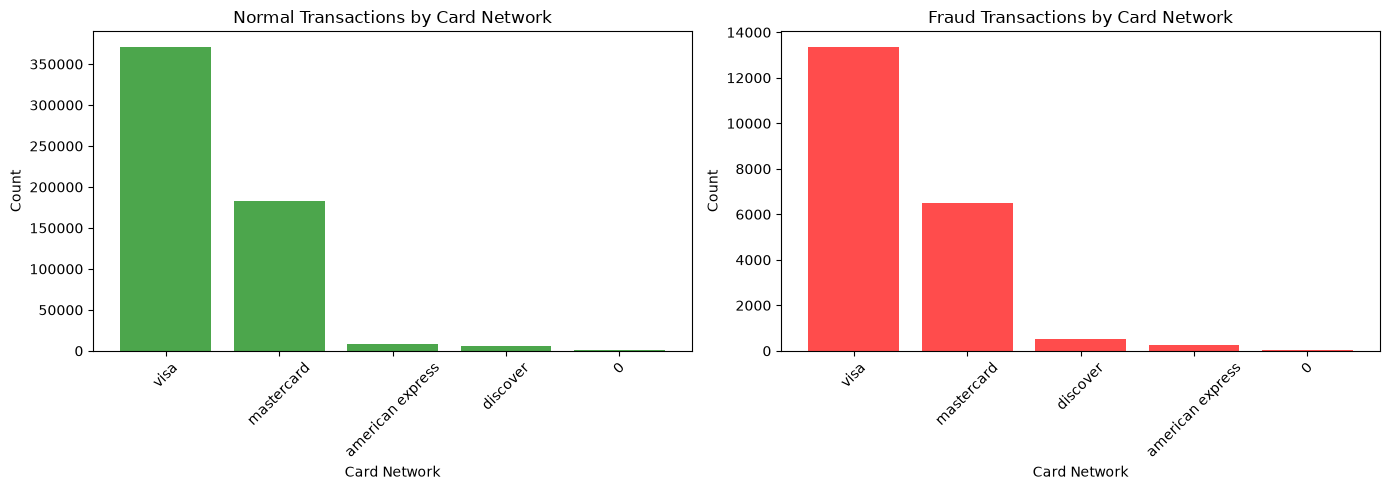


Fraud Rate by Card Network:
discover: 7.73% fraud rate
mastercard: 3.43% fraud rate
visa: 3.48% fraud rate
american express: 2.87% fraud rate
0: 2.60% fraud rate


In [14]:
# Card Type Analysis - Fixed
fig, axes = plt.subplots(1, 2, figsize=(14,5))

card4_normal = df_cleaned[df_cleaned['isFraud']==0]['card4'].value_counts()
card4_fraud = df_cleaned[df_cleaned['isFraud']==1]['card4'].value_counts()

axes[0].bar(range(len(card4_normal)), card4_normal.values, color='green', alpha=0.7)
axes[0].set_xticks(range(len(card4_normal)))
axes[0].set_xticklabels(card4_normal.index, rotation=45)
axes[0].set_title('Normal Transactions by Card Network')
axes[0].set_xlabel('Card Network')
axes[0].set_ylabel('Count')

axes[1].bar(range(len(card4_fraud)), card4_fraud.values, color='red', alpha=0.7)
axes[1].set_xticks(range(len(card4_fraud)))
axes[1].set_xticklabels(card4_fraud.index, rotation=45)
axes[1].set_title('Fraud Transactions by Card Network')
axes[1].set_xlabel('Card Network')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print("\nFraud Rate by Card Network:")
for card in df_cleaned['card4'].unique():
    total = len(df_cleaned[df_cleaned['card4']==card])
    fraud = len(df_cleaned[(df_cleaned['card4']==card) & (df_cleaned['isFraud']==1)])
    if total > 0:
        print(f"{card}: {fraud/total*100:.2f}% fraud rate")

In [15]:
# Check if DeviceType exists
print("DeviceType" in df_cleaned.columns)
print("\nAvailable device/identity columns:")
device_cols = [col for col in df_cleaned.columns if 'device' in col.lower() or 'Device' in col]
print(device_cols)

False

Available device/identity columns:
[]


In [16]:
# Add DeviceType back from original merged data
df_cleaned['DeviceType'] = df['DeviceType']

# Fill missing with 'unknown'
df_cleaned['DeviceType'].fillna('unknown', inplace=True)

print("DeviceType added back!")
print(df_cleaned['DeviceType'].value_counts())

DeviceType added back!
DeviceType
desktop    85165
mobile     55645
Name: count, dtype: int64


In [17]:
print(df_cleaned['DeviceType'].value_counts(dropna=False))
print(f"\nUnknown: {(df_cleaned['DeviceType']=='unknown').sum()}")

DeviceType
NaN        449730
desktop     85165
mobile      55645
Name: count, dtype: int64

Unknown: 0


In [18]:
# Fix DeviceType
df_cleaned['DeviceType'] = df_cleaned['DeviceType'].fillna('unknown')
print(df_cleaned['DeviceType'].value_counts())

DeviceType
unknown    449730
desktop     85165
mobile      55645
Name: count, dtype: int64


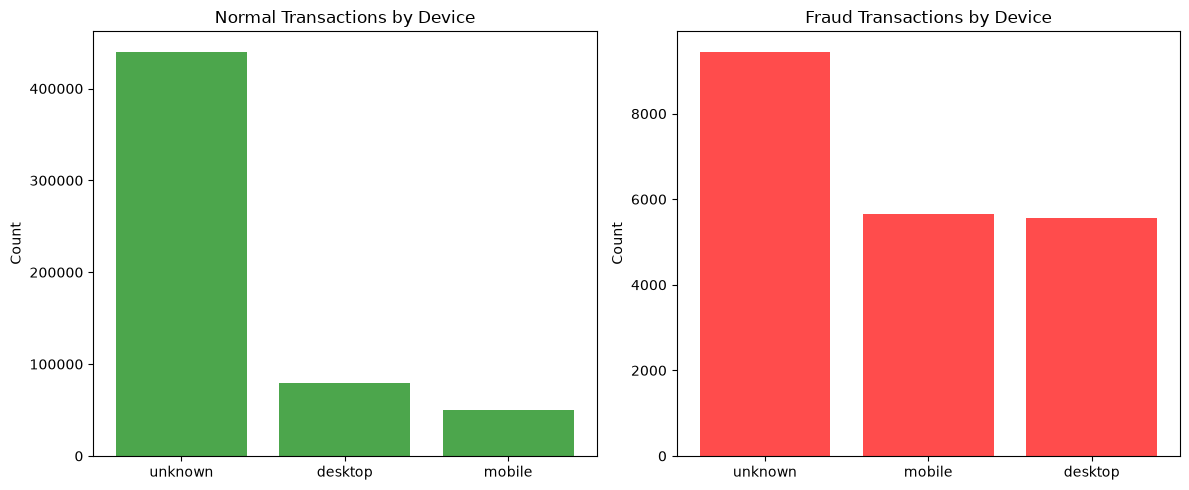


Fraud Rate by Device Type:
desktop: 6.52% fraud rate
mobile: 10.17% fraud rate
unknown: 2.10% fraud rate


In [19]:
# Device Type Analysis
fig, axes = plt.subplots(1, 2, figsize=(12,5))

device_normal = df_cleaned[df_cleaned['isFraud']==0]['DeviceType'].value_counts()
device_fraud = df_cleaned[df_cleaned['isFraud']==1]['DeviceType'].value_counts()

axes[0].bar(range(len(device_normal)), device_normal.values, color='green', alpha=0.7)
axes[0].set_xticks(range(len(device_normal)))
axes[0].set_xticklabels(device_normal.index)
axes[0].set_title('Normal Transactions by Device')
axes[0].set_ylabel('Count')

axes[1].bar(range(len(device_fraud)), device_fraud.values, color='red', alpha=0.7)
axes[1].set_xticks(range(len(device_fraud)))
axes[1].set_xticklabels(device_fraud.index)
axes[1].set_title('Fraud Transactions by Device')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print("\nFraud Rate by Device Type:")
for device in ['desktop', 'mobile', 'unknown']:
    total = len(df_cleaned[df_cleaned['DeviceType']==device])
    fraud = len(df_cleaned[(df_cleaned['DeviceType']==device) & (df_cleaned['isFraud']==1)])
    if total > 0:
        print(f"{device}: {fraud/total*100:.2f}% fraud rate")

In [20]:
# Email Domain Analysis
print("Top 10 Email Domains - Fraud Transactions:")
print(df_cleaned[df_cleaned['isFraud']==1]['P_emaildomain'].value_counts().head(10))

print("\nFraud Rate by Email Domain (Top 10):")
top_domains = df_cleaned['P_emaildomain'].value_counts().head(10).index
for domain in top_domains:
    total = len(df_cleaned[df_cleaned['P_emaildomain']==domain])
    fraud = len(df_cleaned[(df_cleaned['P_emaildomain']==domain) & (df_cleaned['isFraud']==1)])
    if total > 0:
        print(f"{domain}: {fraud/total*100:.2f}% fraud rate")

Top 10 Email Domains - Fraud Transactions:
P_emaildomain
gmail.com        9943
0                2790
hotmail.com      2396
yahoo.com        2297
anonymous.com     859
aol.com           617
outlook.com       482
comcast.net       246
icloud.com        197
mail.com          106
Name: count, dtype: int64

Fraud Rate by Email Domain (Top 10):
gmail.com: 4.35% fraud rate
yahoo.com: 2.28% fraud rate
0: 2.95% fraud rate
hotmail.com: 5.30% fraud rate
anonymous.com: 2.32% fraud rate
aol.com: 2.18% fraud rate
comcast.net: 3.12% fraud rate
icloud.com: 3.14% fraud rate
outlook.com: 9.46% fraud rate
msn.com: 2.20% fraud rate


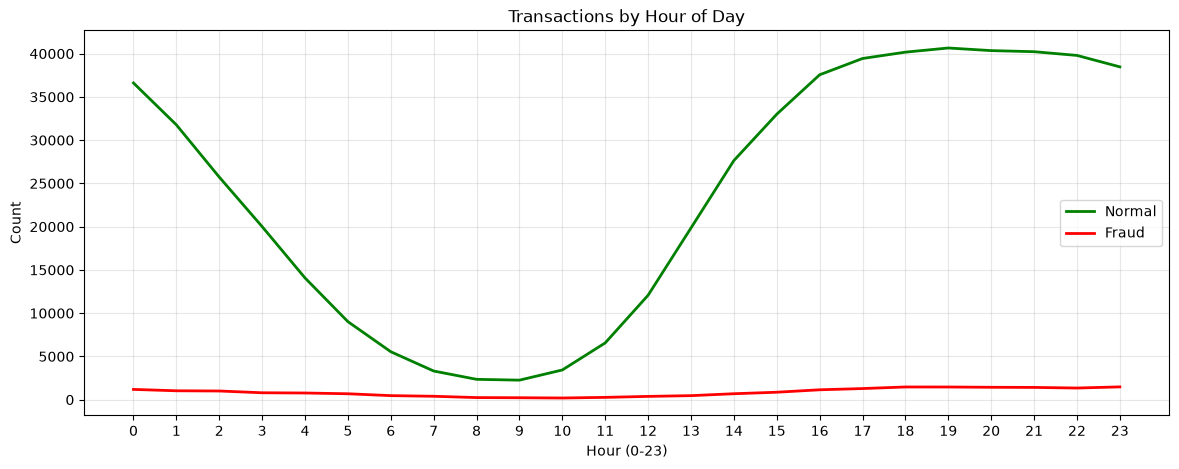


Peak fraud hours:
Transaction_Hour
23    1478
18    1467
19    1463
20    1432
21    1416
Name: count, dtype: int64


In [21]:
# Transaction Time Analysis
df_cleaned['Transaction_Hour'] = (df_cleaned['TransactionDT'] // 3600) % 24

plt.figure(figsize=(14,5))

fraud_hours = df_cleaned[df_cleaned['isFraud']==1]['Transaction_Hour'].value_counts().sort_index()
normal_hours = df_cleaned[df_cleaned['isFraud']==0]['Transaction_Hour'].value_counts().sort_index()

plt.plot(normal_hours.index, normal_hours.values, color='green', label='Normal', linewidth=2)
plt.plot(fraud_hours.index, fraud_hours.values, color='red', label='Fraud', linewidth=2)
plt.title('Transactions by Hour of Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Count')
plt.legend()
plt.xticks(range(0,24))
plt.grid(True, alpha=0.3)
plt.show()

print("\nPeak fraud hours:")
print(fraud_hours.sort_values(ascending=False).head(5))

In [22]:
#DAY 3

In [23]:
# Feature Engineering — New useful features banana

# 1. Transaction Hour already ban gaya hai
# 2. Transaction Day
df_cleaned['Transaction_Day'] = (df_cleaned['TransactionDT'] // (3600*24)) % 7

# 3. High Amount Flag — $500 se zyada = suspicious
df_cleaned['High_Amount'] = (df_cleaned['TransactionAmt'] > 500).astype(int)

# 4. Night Transaction Flag — 11PM to 5AM = suspicious
df_cleaned['Night_Transaction'] = ((df_cleaned['Transaction_Hour'] >= 23) | 
                                    (df_cleaned['Transaction_Hour'] <= 5)).astype(int)

# 5. Amount per card
df_cleaned['Amt_Per_Card'] = df_cleaned['TransactionAmt'] / (df_cleaned['card1'] + 1)

print("New features created!")
print(df_cleaned[['Transaction_Hour', 'Transaction_Day', 
                   'High_Amount', 'Night_Transaction', 
                   'Amt_Per_Card']].head())

New features created!
   Transaction_Hour  Transaction_Day  High_Amount  Night_Transaction  \
0                 0                1            0                  1   
1                 0                1            0                  1   
2                 0                1            0                  1   
3                 0                1            0                  1   
4                 0                1            0                  1   

   Amt_Per_Card  
0      0.004919  
1      0.010522  
2      0.012650  
3      0.002757  
4      0.011116  


In [24]:
from sklearn.preprocessing import LabelEncoder

# Only existing categorical columns encode karo
categorical_cols = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'DeviceType']

le = LabelEncoder()

for col in categorical_cols:
    if col in df_cleaned.columns:
        df_cleaned[col] = le.fit_transform(df_cleaned[col].astype(str))
        print(f"{col} encoded!")

print("\nEncoding complete!")
print(df_cleaned[categorical_cols].head())

ProductCD encoded!
card4 encoded!
card6 encoded!
P_emaildomain encoded!
DeviceType encoded!

Encoding complete!
   ProductCD  card4  card6  P_emaildomain  DeviceType
0          4      2      2              0           2
1          4      3      2             17           2
2          4      4      3             36           2
3          4      3      3             54           2
4          1      3      2             17           1


In [25]:
# Check which columns exist in df_cleaned
print(f"Total columns: {df_cleaned.shape[1]}")
print(f"\nAll columns:")
print(df_cleaned.columns.tolist())

Total columns: 226

All columns:
['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'P_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D10', 'D11', 'D15', 'M1', 'M2', 'M3', 'M4', 'M6', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V82', 'V83', 'V84', 'V85', 'V86', 'V87', 'V88', 'V89', 'V90', 'V91', 'V92', 'V

In [26]:
# Feature Selection
important_features = [
    # Transaction details
    'TransactionAmt', 'ProductCD',
    
    # Card details
    'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
    
    # Address
    'addr1', 'addr2',
    
    # Email
    'P_emaildomain',
    
    # Count features
    'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14',
    
    # Time delta features
    'D1', 'D2', 'D3', 'D4', 'D10', 'D11', 'D15',
    
    # Match features
    'M1', 'M2', 'M3', 'M4', 'M6',
    
    # Vesta features
    'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
    'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
    'V279', 'V280', 'V281', 'V282', 'V283', 'V284', 'V285',
    'V306', 'V307', 'V308', 'V309', 'V310', 'V311', 'V312',
    
    # Device
    'DeviceType',
    
    # Engineered features
    'Transaction_Hour', 'Transaction_Day',
    'High_Amount', 'Night_Transaction', 'Amt_Per_Card'
]

X = df_cleaned[important_features]
y = df_cleaned['isFraud']

print(f"Selected features: {len(important_features)}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFraud cases: {y.sum():,}")
print(f"Normal cases: {(y==0).sum():,}")

Selected features: 77
X shape: (590540, 77)
y shape: (590540,)

Fraud cases: 20,663
Normal cases: 569,877


In [27]:
from sklearn.preprocessing import LabelEncoder

# Only existing categorical columns encode karo
categorical_cols = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'DeviceType']

le = LabelEncoder()

for col in categorical_cols:
    if col in df_cleaned.columns:
        df_cleaned[col] = le.fit_transform(df_cleaned[col].astype(str))
        print(f"{col} encoded!")

print("\nEncoding complete!")
print(df_cleaned[categorical_cols].head())

ProductCD encoded!
card4 encoded!
card6 encoded!
P_emaildomain encoded!
DeviceType encoded!

Encoding complete!
   ProductCD  card4  card6  P_emaildomain  DeviceType
0          4      2      2              0           2
1          4      3      2              9           2
2          4      4      3             30           2
3          4      3      3             50           2
4          1      3      2              9           1


In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training size: {X_train.shape}")
print(f"Testing size: {X_test.shape}")
print(f"\nTraining fraud count: {y_train.sum():,}")
print(f"Testing fraud count: {y_test.sum():,}")
print(f"\nTraining fraud %: {y_train.mean()*100:.2f}%")
print(f"Testing fraud %: {y_test.mean()*100:.2f}%")

Training size: (472432, 77)
Testing size: (118108, 77)

Training fraud count: 16,530
Testing fraud count: 4,133

Training fraud %: 3.50%
Testing fraud %: 3.50%


In [29]:
# Check which columns have string values
for col in X_train.columns:
    if X_train[col].dtype == 'object':
        print(f"String column found: {col}")
        print(X_train[col].unique()[:5])

String column found: M1
[0 'T' 'F']
String column found: M2
[0 'T' 'F']
String column found: M3
[0 'T' 'F']
String column found: M4
[0 'M0' 'M2' 'M1']
String column found: M6
[0 'F' 'T']


In [30]:
# Encode M columns
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

m_cols = ['M1', 'M2', 'M3', 'M4', 'M6']

for col in m_cols:
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))
    print(f"{col} encoded!")

print("\nAll M columns encoded!")

M1 encoded!
M2 encoded!
M3 encoded!
M4 encoded!
M6 encoded!

All M columns encoded!


In [31]:
from imblearn.over_sampling import SMOTE

print("Applying SMOTE...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"\nBefore SMOTE:")
print(f"Normal: {(y_train==0).sum():,}")
print(f"Fraud: {(y_train==1).sum():,}")

print(f"\nAfter SMOTE:")
print(f"Normal: {(y_train_smote==0).sum():,}")
print(f"Fraud: {(y_train_smote==1).sum():,}")

Applying SMOTE...

Before SMOTE:
Normal: 455,902
Fraud: 16,530

After SMOTE:
Normal: 455,902
Fraud: 455,902


In [32]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score

# LightGBM Model
print("Training LightGBM...")
lgbm_model = LGBMClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    verbose=-1
)

lgbm_model.fit(X_train_smote, y_train_smote)
print("LightGBM training complete!")

Training LightGBM...
LightGBM training complete!


In [33]:
# Predictions
y_pred = lgbm_model.predict(X_test)
y_pred_prob = lgbm_model.predict_proba(X_test)[:,1]

# Results
print("LightGBM Results:")
print(f"AUC Score: {roc_auc_score(y_test, y_pred_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

LightGBM Results:
AUC Score: 0.8875

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98    113975
           1       0.53      0.49      0.51      4133

    accuracy                           0.97    118108
   macro avg       0.76      0.73      0.74    118108
weighted avg       0.97      0.97      0.97    118108



In [34]:
# Threshold tuning
from sklearn.metrics import classification_report

for threshold in [0.5, 0.4, 0.3, 0.2]:
    y_pred_new = (y_pred_prob >= threshold).astype(int)
    fraud_recall = classification_report(y_test, y_pred_new, output_dict=True)['1']['recall']
    fraud_precision = classification_report(y_test, y_pred_new, output_dict=True)['1']['precision']
    print(f"Threshold {threshold}: Recall={fraud_recall:.2f}, Precision={fraud_precision:.2f}")

Threshold 0.5: Recall=0.49, Precision=0.53
Threshold 0.4: Recall=0.54, Precision=0.43
Threshold 0.3: Recall=0.61, Precision=0.33
Threshold 0.2: Recall=0.70, Precision=0.23


In [35]:
# Better LightGBM with tuned parameters
print("Training improved LightGBM...")
lgbm_model_v2 = LGBMClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

lgbm_model_v2.fit(X_train_smote, y_train_smote)
print("Improved LightGBM training complete!")

Training improved LightGBM...
Improved LightGBM training complete!


In [36]:
# Improved LightGBM Results
y_pred_v2 = lgbm_model_v2.predict(X_test)
y_pred_prob_v2 = lgbm_model_v2.predict_proba(X_test)[:,1]

print("Improved LightGBM Results:")
print(f"AUC Score: {roc_auc_score(y_test, y_pred_prob_v2):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_v2))

# Threshold tuning
print("\nThreshold Tuning:")
for threshold in [0.5, 0.4, 0.3, 0.2]:
    y_pred_new = (y_pred_prob_v2 >= threshold).astype(int)
    recall = classification_report(y_test, y_pred_new, output_dict=True)['1']['recall']
    precision = classification_report(y_test, y_pred_new, output_dict=True)['1']['precision']
    print(f"Threshold {threshold}: Recall={recall:.2f}, Precision={precision:.2f}")

Improved LightGBM Results:
AUC Score: 0.9149

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99    113975
           1       0.74      0.45      0.56      4133

    accuracy                           0.98    118108
   macro avg       0.86      0.72      0.78    118108
weighted avg       0.97      0.98      0.97    118108


Threshold Tuning:
Threshold 0.5: Recall=0.45, Precision=0.74
Threshold 0.4: Recall=0.51, Precision=0.66
Threshold 0.3: Recall=0.57, Precision=0.55
Threshold 0.2: Recall=0.64, Precision=0.42


In [37]:
from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_smote, y_train_smote)
print("Random Forest training complete!")

Training Random Forest...
Random Forest training complete!


In [38]:
# Random Forest Results
rf_pred = rf_model.predict(X_test)
rf_pred_prob = rf_model.predict_proba(X_test)[:,1]

print("Random Forest Results:")
print(f"AUC Score: {roc_auc_score(y_test, rf_pred_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

# Threshold tuning
print("\nThreshold Tuning:")
for threshold in [0.5, 0.4, 0.3, 0.2]:
    y_pred_new = (rf_pred_prob >= threshold).astype(int)
    recall = classification_report(y_test, y_pred_new, output_dict=True)['1']['recall']
    precision = classification_report(y_test, y_pred_new, output_dict=True)['1']['precision']
    print(f"Threshold {threshold}: Recall={recall:.2f}, Precision={precision:.2f}")

Random Forest Results:
AUC Score: 0.9240

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    113975
           1       0.88      0.51      0.64      4133

    accuracy                           0.98    118108
   macro avg       0.93      0.75      0.82    118108
weighted avg       0.98      0.98      0.98    118108


Threshold Tuning:
Threshold 0.5: Recall=0.51, Precision=0.87
Threshold 0.4: Recall=0.58, Precision=0.81
Threshold 0.3: Recall=0.64, Precision=0.69
Threshold 0.2: Recall=0.72, Precision=0.50


In [39]:
# Add more V features
important_features_v2 = [
    'TransactionAmt', 'ProductCD',
    'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
    'addr1', 'addr2',
    'P_emaildomain',
    'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14',
    'D1', 'D2', 'D3', 'D4', 'D10', 'D11', 'D15',
    'M1', 'M2', 'M3', 'M4', 'M6',
    # More V features
    'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
    'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
    'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30',
    'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40',
    'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50',
    'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60',
    'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70',
    'V279', 'V280', 'V281', 'V282', 'V283', 'V284', 'V285', 'V286', 'V287',
    'V306', 'V307', 'V308', 'V309', 'V310', 'V311', 'V312', 'V313', 'V314',
    'DeviceType',
    'Transaction_Hour', 'Transaction_Day',
    'High_Amount', 'Night_Transaction', 'Amt_Per_Card'
]

# Only keep existing columns
important_features_v2 = [f for f in important_features_v2 if f in df_cleaned.columns]

X_v2 = df_cleaned[important_features_v2]
y_v2 = df_cleaned['isFraud']

print(f"New feature count: {len(important_features_v2)}")

New feature count: 131


In [40]:
# Train/Test Split
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y_v2, test_size=0.2, random_state=42, stratify=y_v2)

# Encode M columns
m_cols = ['M1', 'M2', 'M3', 'M4', 'M6']
for col in m_cols:
    if col in X_train_v2.columns:
        X_train_v2[col] = le.fit_transform(X_train_v2[col].astype(str))
        X_test_v2[col] = le.transform(X_test_v2[col].astype(str))

# SMOTE
print("Applying SMOTE...")
smote = SMOTE(random_state=42)
X_train_v2_smote, y_train_v2_smote = smote.fit_resample(X_train_v2, y_train_v2)

print(f"Training size after SMOTE: {X_train_v2_smote.shape}")
print("Ready for training!")

Applying SMOTE...
Training size after SMOTE: (911804, 131)
Ready for training!


In [41]:
from sklearn.ensemble import RandomForestClassifier

print("Training improved Random Forest...")
rf_model_v2 = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1,
    class_weight={0:1, 1:3}  # Fraud ko 3x importance
)

rf_model_v2.fit(X_train_v2_smote, y_train_v2_smote)
print("Training complete!")

Training improved Random Forest...
Training complete!


In [42]:
# Results
rf_pred_v2 = rf_model_v2.predict(X_test_v2)
rf_pred_prob_v2 = rf_model_v2.predict_proba(X_test_v2)[:,1]

print("Improved Random Forest Results:")
print(f"AUC Score: {roc_auc_score(y_test_v2, rf_pred_prob_v2):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_v2, rf_pred_v2))

print("\nThreshold Tuning:")
for threshold in [0.5, 0.4, 0.3, 0.2]:
    y_pred_new = (rf_pred_prob_v2 >= threshold).astype(int)
    recall = classification_report(y_test_v2, y_pred_new, output_dict=True)['1']['recall']
    precision = classification_report(y_test_v2, y_pred_new, output_dict=True)['1']['precision']
    print(f"Threshold {threshold}: Recall={recall:.2f}, Precision={precision:.2f}")

Improved Random Forest Results:
AUC Score: 0.9072

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.94      0.96    113975
           1       0.29      0.71      0.41      4133

    accuracy                           0.93    118108
   macro avg       0.64      0.82      0.69    118108
weighted avg       0.96      0.93      0.94    118108


Threshold Tuning:
Threshold 0.5: Recall=0.71, Precision=0.29
Threshold 0.4: Recall=0.77, Precision=0.20
Threshold 0.3: Recall=0.84, Precision=0.14
Threshold 0.2: Recall=0.90, Precision=0.09


In [43]:
import joblib
import json

joblib.dump(rf_model, 'fraud_model.pkl')

with open('model_config.json', 'w') as f:
    json.dump({'threshold': 0.2}, f)

print("Model saved!")

Model saved!


In [44]:
import joblib
import json

# Save RF v2 - best recall
joblib.dump(rf_model_v2, 'fraud_model.pkl')

with open('model_config.json', 'w') as f:
    json.dump({
        'threshold': 0.2,
        'model': 'RandomForest_v2',
        'recall': 0.90,
        'precision': 0.09,
        'auc': 0.9072
    }, f)

print("Best model saved!")
print("Threshold: 0.2")
print("Recall: 90%")
print("AUC: 0.9072")

Best model saved!
Threshold: 0.2
Recall: 90%
AUC: 0.9072


In [45]:
import joblib
import json

# Save RF v1 - better balance
joblib.dump(rf_model, 'fraud_model.pkl')

with open('model_config.json', 'w') as f:
    json.dump({
        'threshold': 0.3,
        'model': 'RandomForest_v1',
        'recall': 0.64,
        'precision': 0.69,
        'auc': 0.9240
    }, f)

print("RF v1 saved with threshold 0.3!")

RF v1 saved with threshold 0.3!


In [46]:
# Check feature order in RF v1
print(X_train.columns.tolist())

['TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'P_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D10', 'D11', 'D15', 'M1', 'M2', 'M3', 'M4', 'M6', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V279', 'V280', 'V281', 'V282', 'V283', 'V284', 'V285', 'V306', 'V307', 'V308', 'V309', 'V310', 'V311', 'V312', 'DeviceType', 'Transaction_Hour', 'Transaction_Day', 'High_Amount', 'Night_Transaction', 'Amt_Per_Card']


In [47]:
import joblib
import json

joblib.dump(rf_model, 'fraud_model.pkl')

with open('model_config.json', 'w') as f:
    json.dump({
        'threshold': 0.6,
        'model': 'RandomForest_v1',
        'recall': 0.58,
        'precision': 0.81,
        'auc': 0.9240
    }, f)

print("Saved with threshold 0.6!")

Saved with threshold 0.6!


Top 20 Most Important Features:
           feature  importance
24             C14    0.047846
23             C13    0.043421
11              C1    0.039902
12              C2    0.038238
58            V280    0.038106
20             C10    0.037117
18              C8    0.036351
14              C4    0.034215
57            V279    0.023982
64            V306    0.022779
27              D3    0.022202
21             C11    0.021621
1        ProductCD    0.020038
22             C12    0.020021
17              C7    0.019893
15              C5    0.019714
66            V308    0.019381
16              C6    0.017168
61            V283    0.017144
0   TransactionAmt    0.016856


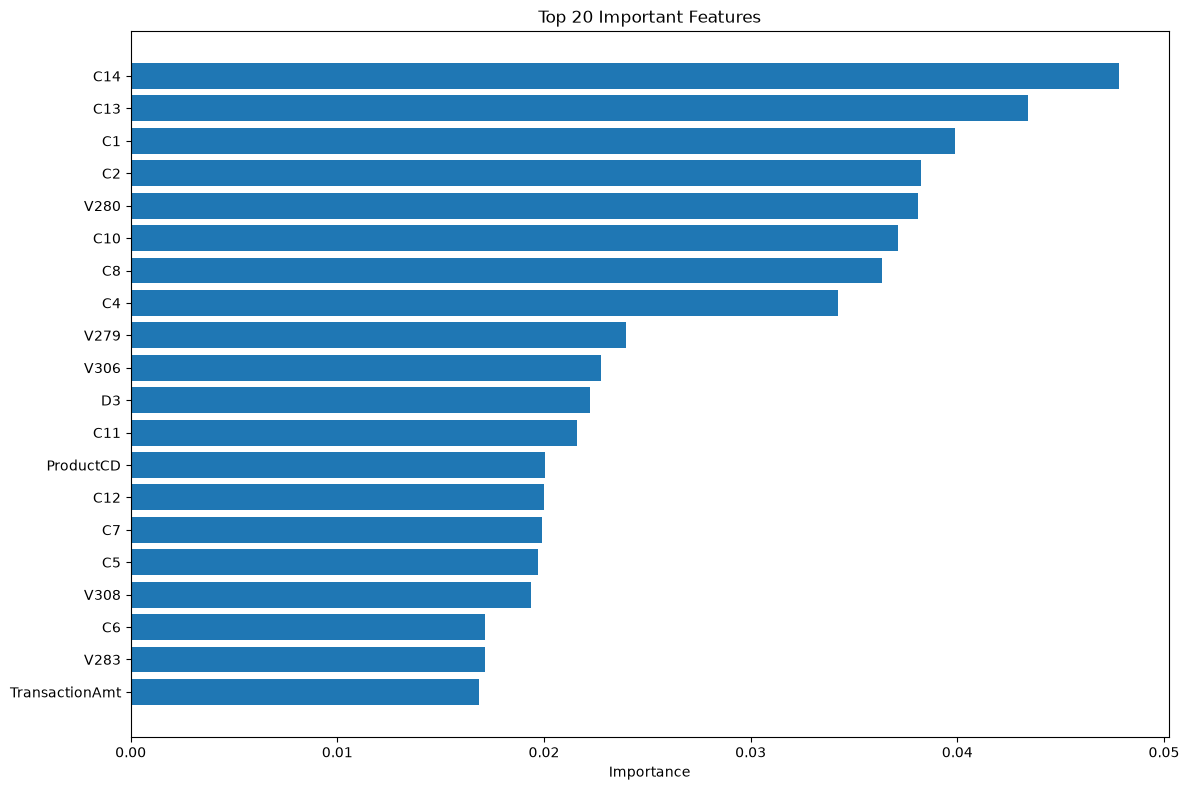

In [48]:
# Feature Importance check karo
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 20 Most Important Features:")
print(feature_importance.head(20))

# Graph
plt.figure(figsize=(12,8))
plt.barh(feature_importance.head(20)['feature'], 
         feature_importance.head(20)['importance'])
plt.title('Top 20 Important Features')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [49]:
# Pehle sab 220 features pe model train karo
from sklearn.ensemble import RandomForestClassifier

X_all = df_cleaned.drop(['TransactionID', 'isFraud', 'TransactionDT'], axis=1)
y_all = df_cleaned['isFraud']

# Quick train with all features
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all)

print(f"Total features: {X_all.shape[1]}")
print("Checking feature importance on all features...")

Total features: 223
Checking feature importance on all features...


In [50]:
# Quick RF on all 223 features
rf_all = RandomForestClassifier(
    n_estimators=50,  # Fast training ke liye kam trees
    random_state=42,
    n_jobs=-1
)

# M columns encode karo pehle
m_cols = ['M1', 'M2', 'M3', 'M4', 'M6']
for col in m_cols:
    if col in X_train_all.columns:
        X_train_all[col] = le.fit_transform(X_train_all[col].astype(str))
        X_test_all[col] = le.transform(X_test_all[col].astype(str))

print("Training on all 223 features...")
rf_all.fit(X_train_all, y_train_all)
print("Done!")

Training on all 223 features...
Done!


Top 30 Most Important Features:
              feature  importance
222      Amt_Per_Card    0.042901
0      TransactionAmt    0.037114
2               card1    0.035515
11                 C1    0.033448
3               card2    0.029475
218  Transaction_Hour    0.028047
23                C13    0.027014
8               addr1    0.024601
12                 C2    0.022029
81                V45    0.021937
24                C14    0.021449
219   Transaction_Day    0.021066
10      P_emaildomain    0.020074
21                C11    0.017565
14                 C4    0.017142
6               card5    0.015836
18                 C8    0.015180
20                C10    0.013301
31                D15    0.012853
16                 C6    0.012546
123               V87    0.010962
28                 D4    0.010865
25                 D1    0.010857
26                 D2    0.010318
22                C12    0.010123
202              V307    0.009649
29                D10    0.009344
80              

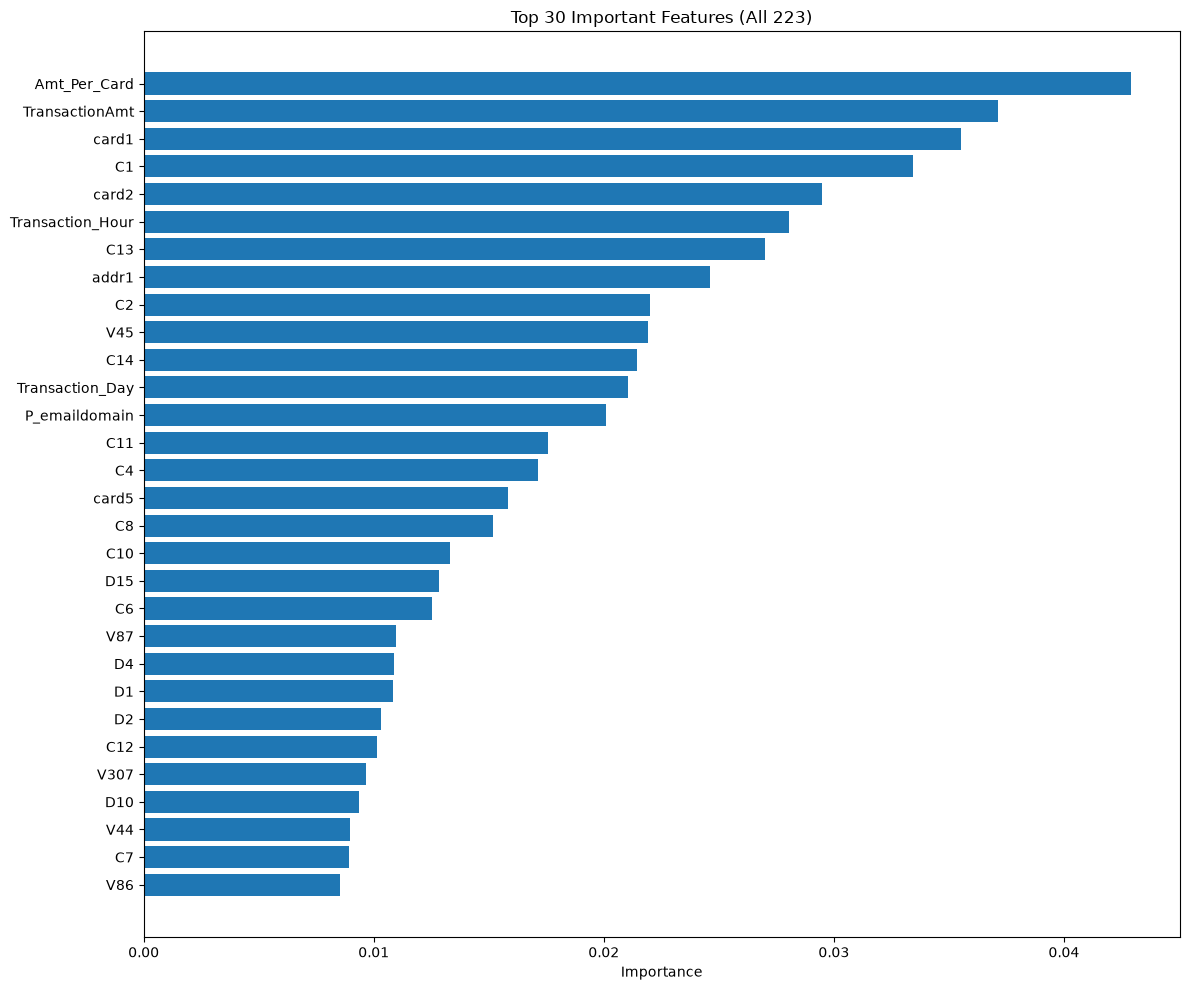

In [51]:
# Feature importance on all 223 features
feature_importance_all = pd.DataFrame({
    'feature': X_train_all.columns,
    'importance': rf_all.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 30 Most Important Features:")
print(feature_importance_all.head(30))

# Graph
plt.figure(figsize=(12,10))
plt.barh(feature_importance_all.head(30)['feature'], 
         feature_importance_all.head(30)['importance'])
plt.title('Top 30 Important Features (All 223)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [52]:
# C features ka matlab
print("C features description:")
print(df_cleaned[['C1','C2','C4','C6','C8','C10','C11','C13','C14']].describe())

C features description:
                  C1             C2             C4             C6  \
count  590540.000000  590540.000000  590540.000000  590540.000000   
mean       14.092458      15.269734       4.092185       9.071082   
std       133.569018     154.668899      68.848459      71.508467   
min         0.000000       0.000000       0.000000       0.000000   
25%         1.000000       1.000000       0.000000       1.000000   
50%         1.000000       1.000000       0.000000       1.000000   
75%         3.000000       3.000000       0.000000       2.000000   
max      4685.000000    5691.000000    2253.000000    2253.000000   

                  C8            C10            C11            C13  \
count  590540.000000  590540.000000  590540.000000  590540.000000   
mean        5.144574       5.240343      10.241521      32.539918   
std        95.378574      95.581443      94.336292     129.364844   
min         0.000000       0.000000       0.000000       0.000000   
25%      

In [53]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

# Encode M columns
m_cols = ['M1', 'M2', 'M3', 'M4', 'M6']
for col in m_cols:
    if col in X_train_all.columns:
        X_train_all[col] = le.fit_transform(X_train_all[col].astype(str))
        X_test_all[col] = le.transform(X_test_all[col].astype(str))

# SMOTE
print("Applying SMOTE...")
smote = SMOTE(random_state=42)
X_train_all_smote, y_train_all_smote = smote.fit_resample(X_train_all, y_train_all)
print(f"After SMOTE: {X_train_all_smote.shape}")

# Train model
print("Training RF on all 223 features...")
rf_final = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_final.fit(X_train_all_smote, y_train_all_smote)
print("Training complete!")

Applying SMOTE...
After SMOTE: (911804, 223)
Training RF on all 223 features...
Training complete!


In [54]:
from sklearn.metrics import classification_report, roc_auc_score

rf_final_pred = rf_final.predict(X_test_all)
rf_final_prob = rf_final.predict_proba(X_test_all)[:,1]

print("RF Final Results (223 features):")
print(f"AUC Score: {roc_auc_score(y_test_all, rf_final_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_all, rf_final_pred))

print("\nThreshold Tuning:")
for threshold in [0.5, 0.4, 0.3, 0.2]:
    y_pred_new = (rf_final_prob >= threshold).astype(int)
    recall = classification_report(y_test_all, y_pred_new, output_dict=True)['1']['recall']
    precision = classification_report(y_test_all, y_pred_new, output_dict=True)['1']['precision']
    print(f"Threshold {threshold}: Recall={recall:.2f}, Precision={precision:.2f}")

RF Final Results (223 features):
AUC Score: 0.9212

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    113975
           1       0.87      0.48      0.62      4133

    accuracy                           0.98    118108
   macro avg       0.93      0.74      0.80    118108
weighted avg       0.98      0.98      0.98    118108


Threshold Tuning:
Threshold 0.5: Recall=0.49, Precision=0.87
Threshold 0.4: Recall=0.55, Precision=0.80
Threshold 0.3: Recall=0.62, Precision=0.67
Threshold 0.2: Recall=0.71, Precision=0.48


In [55]:
import joblib
import json

joblib.dump(rf_final, 'fraud_model.pkl')

with open('model_config.json', 'w') as f:
    json.dump({
        'threshold': 0.3,
        'model': 'RandomForest_223features',
        'recall': 0.62,
        'precision': 0.67,
        'auc': 0.9212,
        'features': X_train_all.columns.tolist()
    }, f)

print("Model saved!")

Model saved!


In [56]:
import joblib
import json

joblib.dump(rf_final, 'fraud_model.pkl')

with open('model_config.json', 'w') as f:
    json.dump({
        'threshold': 0.2,
        'model': 'RandomForest_223features',
        'recall': 0.71,
        'precision': 0.48,
        'auc': 0.9212,
        'features': X_train_all.columns.tolist()
    }, f)

print("Saved with threshold 0.2!")

Saved with threshold 0.2!


In [57]:
with open('model_config.json', 'w') as f:
    json.dump({
        'threshold': 0.25,
        'model': 'RandomForest_223features',
        'features': X_train_all.columns.tolist()
    }, f)

print("Saved with threshold 0.25!")

Saved with threshold 0.25!


In [58]:
# Check actual probabilities on test data
normal_probs = rf_final_prob[y_test_all == 0]
fraud_probs = rf_final_prob[y_test_all == 1]

print(f"Normal transactions average probability: {normal_probs.mean():.3f}")
print(f"Fraud transactions average probability: {fraud_probs.mean():.3f}")
print(f"\nNormal 75th percentile: {np.percentile(normal_probs, 75):.3f}")
print(f"Fraud 25th percentile: {np.percentile(fraud_probs, 25):.3f}")

Normal transactions average probability: 0.033
Fraud transactions average probability: 0.494

Normal 75th percentile: 0.040
Fraud 25th percentile: 0.150


In [59]:
print(threshold)  # model_config.json se

0.2


In [60]:
import json
with open('model_config.json') as f:
    config = json.load(f)
print(config['threshold'])

0.25


In [61]:
import pandas as pd
importances = pd.Series(rf_final.feature_importances_, index=X_train_all.columns)
top20 = importances.sort_values(ascending=False).head(20)
print(top20)

C14               0.038782
C13               0.035953
C10               0.027832
C2                0.025652
C1                0.023190
C4                0.021701
C11               0.018737
C8                0.016751
V304              0.016628
C6                0.014070
V280              0.013548
V302              0.013205
TransactionAmt    0.012828
V303              0.012095
V279              0.012053
V29               0.011987
V70               0.011481
V91               0.011196
card1             0.010903
V51               0.010898
dtype: float64


In [62]:
fraud_row = X_test_all[y_test_all == 1].iloc[0]
legit_row = X_test_all[y_test_all == 0].iloc[0]

cols = ['TransactionAmt','card1','C1','C2','C4','C6','C8','C10','C11','C13','C14',
        'V29','V51','V70','V91','V279','V280','V302','V303','V304']

print("FRAUD:", fraud_row[cols].to_dict())
print("LEGIT:", legit_row[cols].to_dict())

FRAUD: {'TransactionAmt': 11.427, 'card1': 16746.0, 'C1': 14.0, 'C2': 22.0, 'C4': 10.0, 'C6': 10.0, 'C8': 14.0, 'C10': 11.0, 'C11': 20.0, 'C13': 6.0, 'C14': 4.0, 'V29': 0.0, 'V51': 1.0, 'V70': 0.0, 'V91': 0.0, 'V279': 0.0, 'V280': 0.0, 'V302': 1.0, 'V303': 1.0, 'V304': 1.0}
LEGIT: {'TransactionAmt': 107.95, 'card1': 7585.0, 'C1': 2.0, 'C2': 2.0, 'C4': 0.0, 'C6': 2.0, 'C8': 0.0, 'C10': 0.0, 'C11': 1.0, 'C13': 9.0, 'C14': 2.0, 'V29': 1.0, 'V51': 0.0, 'V70': 1.0, 'V91': 1.0, 'V279': 0.0, 'V280': 0.0, 'V302': 0.0, 'V303': 0.0, 'V304': 0.0}


In [63]:
# Get probabilities for full test set
probs = rf_final.predict_proba(X_test_all)[:, 1]

# Find index of highest fraud probability (closest to 100%)
max_idx = probs.argmax()
print("Highest fraud probability:", probs[max_idx])
print("Actual label:", y_test_all.iloc[max_idx])

# Find index of lowest fraud probability (closest to 0%)
min_idx = probs.argmin()
print("Lowest fraud probability:", probs[min_idx])
print("Actual label:", y_test_all.iloc[min_idx])

cols = ['TransactionAmt','card1','C1','C2','C4','C6','C8','C10','C11','C13','C14',
        'V29','V51','V70','V91','V279','V280','V302','V303','V304']

print("EXTREME FRAUD ROW:", X_test_all.iloc[max_idx][cols].to_dict())
print("EXTREME LEGIT ROW:", X_test_all.iloc[min_idx][cols].to_dict())

Highest fraud probability: 1.0
Actual label: 1
Lowest fraud probability: 0.0
Actual label: 0
EXTREME FRAUD ROW: {'TransactionAmt': 31.66, 'card1': 2675.0, 'C1': 11.0, 'C2': 11.0, 'C4': 1.0, 'C6': 1.0, 'C8': 1.0, 'C10': 2.0, 'C11': 2.0, 'C13': 0.0, 'C14': 0.0, 'V29': 0.0, 'V51': 1.0, 'V70': 0.0, 'V91': 0.0, 'V279': 0.0, 'V280': 0.0, 'V302': 1.0, 'V303': 1.0, 'V304': 1.0}
EXTREME LEGIT ROW: {'TransactionAmt': 107.95, 'card1': 7585.0, 'C1': 2.0, 'C2': 2.0, 'C4': 0.0, 'C6': 2.0, 'C8': 0.0, 'C10': 0.0, 'C11': 1.0, 'C13': 9.0, 'C14': 2.0, 'V29': 1.0, 'V51': 0.0, 'V70': 1.0, 'V91': 1.0, 'V279': 0.0, 'V280': 0.0, 'V302': 0.0, 'V303': 0.0, 'V304': 0.0}


In [64]:
probs = rf_final.predict_proba(X_test_all)[:, 1]
cols = ['TransactionAmt','card1','C1','C2','C4','C6','C8','C10','C11','C13','C14',
        'V29','V51','V70','V91','V279','V280','V302','V303','V304']

import numpy as np
fraud_idx = np.where(y_test_all.values == 1)[0]
legit_idx = np.where(y_test_all.values == 0)[0]

for i in [0, 5, 15, 30]:
    idx = fraud_idx[np.argsort(-probs[fraud_idx])][i]
    print(f"FRAUD (prob={probs[idx]:.2f}):", X_test_all.iloc[idx][cols].to_dict())

for i in [0, 5, 15, 30]:
    idx = legit_idx[np.argsort(probs[legit_idx])][i]
    print(f"LEGIT (prob={probs[idx]:.2f}):", X_test_all.iloc[idx][cols].to_dict())

FRAUD (prob=1.00): {'TransactionAmt': 24.346, 'card1': 9633.0, 'C1': 6.0, 'C2': 9.0, 'C4': 4.0, 'C6': 4.0, 'C8': 5.0, 'C10': 4.0, 'C11': 5.0, 'C13': 1.0, 'C14': 1.0, 'V29': 0.0, 'V51': 1.0, 'V70': 0.0, 'V91': 0.0, 'V279': 1.0, 'V280': 1.0, 'V302': 2.0, 'V303': 2.0, 'V304': 2.0}
FRAUD (prob=1.00): {'TransactionAmt': 10.876, 'card1': 9633.0, 'C1': 12.0, 'C2': 22.0, 'C4': 6.0, 'C6': 6.0, 'C8': 8.0, 'C10': 11.0, 'C11': 8.0, 'C13': 3.0, 'C14': 1.0, 'V29': 0.0, 'V51': 1.0, 'V70': 0.0, 'V91': 0.0, 'V279': 0.0, 'V280': 0.0, 'V302': 1.0, 'V303': 1.0, 'V304': 1.0}
FRAUD (prob=1.00): {'TransactionAmt': 86.318, 'card1': 9633.0, 'C1': 335.0, 'C2': 620.0, 'C4': 88.0, 'C6': 88.0, 'C8': 122.0, 'C10': 113.0, 'C11': 135.0, 'C13': 18.0, 'C14': 13.0, 'V29': 0.0, 'V51': 1.0, 'V70': 0.0, 'V91': 0.0, 'V279': 0.0, 'V280': 0.0, 'V302': 1.0, 'V303': 1.0, 'V304': 1.0}
FRAUD (prob=1.00): {'TransactionAmt': 14.325, 'card1': 5812.0, 'C1': 42.0, 'C2': 78.0, 'C4': 5.0, 'C6': 5.0, 'C8': 15.0, 'C10': 11.0, 'C11': 8.0, 

In [65]:
import numpy as np, json

probs = rf_final.predict_proba(X_test_all)[:, 1]

fraud_idx = np.where(y_test_all.values == 1)[0]
legit_idx = np.where(y_test_all.values == 0)[0]

sorted_fraud = fraud_idx[np.argsort(-probs[fraud_idx])]
sorted_legit = legit_idx[np.argsort(probs[legit_idx])]

fraud_picks = [sorted_fraud[i] for i in [0, 5, 15, 30]]
legit_picks = [sorted_legit[i] for i in [0, 5, 15, 30]]

examples = {"fraud": [], "legit": []}

for idx in fraud_picks:
    examples["fraud"].append({
        "prob": float(probs[idx]),
        "features": X_test_all.iloc[idx].to_dict()
    })

for idx in legit_picks:
    examples["legit"].append({
        "prob": float(probs[idx]),
        "features": X_test_all.iloc[idx].to_dict()
    })

with open("demo_examples.json", "w") as f:
    json.dump(examples, f, indent=2)

print("Saved! fraud:", len(examples["fraud"]), "legit:", len(examples["legit"]))

Saved! fraud: 4 legit: 4


In [67]:
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(X, y, test_size=0.2, random_state=42)